<a href="https://colab.research.google.com/github/panithan1991/Exploring-Thailand-s-Government-Procurement-Spending/blob/main/notebook/03_construction_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DADS5001 Mini Project
## Exploratory Data Analysis of Government Construction Procurement

Notebook นี้วิเคราะห์ข้อมูลโครงการจ้างก่อสร้างภาครัฐ
ปีงบประมาณ 2569 เพื่อทำความเข้าใจลักษณะของโครงการ
การกระจายของมูลค่า วิธีจัดซื้อ หน่วยงาน พื้นที่ และผู้รับจ้าง

### Main Questions

1. โครงการจ้างก่อสร้างมีมูลค่ากระจายตัวอย่างไร
2. ราคาที่ตกลงแตกต่างจากวงเงินงบประมาณและราคากลางเพียงใด
3. รูปแบบของราคาแตกต่างกันตามวิธีจัดซื้อจัดจ้างหรือไม่
4. หน่วยงานและพื้นที่ใดมีจำนวนหรือมูลค่าโครงการสูง
5. ผู้รับจ้างมีการกระจุกตัวมากน้อยเพียงใด
6. มีรูปแบบใดที่ควรนำไปตรวจสอบเพิ่มเติม

### Scope

- ใช้ข้อมูลเฉพาะ `จ้างก่อสร้าง` ปีงบประมาณ 2569
- วิเคราะห์ภาพรวมที่ระดับโครงการโดยใช้ `รหัสโครงการ`
- ใช้ข้อมูลทุกแถวเมื่อต้องวิเคราะห์ผู้ชนะหรือรายละเอียดสัญญา
- เน้น Pandas, NumPy, Matplotlib และ Seaborn
- ยังไม่กำหนด Red Flag จนกว่าจะเห็นผลจาก EDA

> รูปแบบที่ผิดสังเกตเป็นเพียงสัญญาณที่ควรตรวจสอบเพิ่มเติม
> ไม่ใช่หลักฐานยืนยันการทุจริต

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 100)
pd.set_option(
    'display.float_format',
    lambda value: f'{value:,.2f}'
)

sns.set_theme(style='whitegrid')

data_path = Path('/content/drive/MyDrive/learning/dads/dads5001/project_1_dads5001/dataset/procurement/egp-contract/processed/construction_contracts_2569.csv')

construction_data = pd.read_csv(data_path,low_memory=False)

print(f'Shape: {construction_data.shape}')

Shape: (180079, 29)


## 1. Data Understanding

เริ่มจากตรวจสอบโครงสร้าง ชนิดข้อมูล ค่าว่าง และจำนวนค่าที่ไม่ซ้ำ
ของแต่ละคอลัมน์ เพื่อเลือกตัวแปรที่สามารถนำมาใช้วิเคราะห์ได้จริง

การตรวจในส่วนนี้มุ่งเฉพาะข้อมูลที่จำเป็นต่อ EDA
ไม่ใช่การทำ Data-quality audit อย่างละเอียด

In [ ]:
display(construction_data.head())

,ลำดับ,รหัสโครงการ,ชื่อโครงการจัดซื้อจัดจ้าง,ชื่อประเภทโครงการ,ชื่อหน่วยงาน,ชื่อหน่วยงานย่อย,ชื่อวิธีการจัดซื้อจัดจ้าง,ชื่อกลุ่มวิธีการจัดซื้อจัดจ้าง,วันที่ประกาศจัดซื้อจัดจ้าง,วงเงินงบประมาณ (บาท),ราคากลาง (บาท),ราคาที่ตกลงซื้อ / จ้าง ซึ่งรวมทุกสัญญาในโครงการ (บาท),ปีงบประมาณ,วันที่เกิดรายการ,จังหวัด,เขต/อำเภอ,แขวง/ตำบล,สถานะโครงการ,พิกัดของโครงการ,ละติจูดของโครงการ,ลองจิจูดของโครงการ,เลขประจำตัวนิติบุคคล 13 หลัก,ชื่อผู้ชนะการเสนอราคา,เลขที่สัญญา,วันที่ลงนามในสัญญา,วันที่สิ้นสุดสัญญา,วงเงินงบประมาณในสัญญา (บาท),สถานะสัญญา,source_file
0,2,67079254388,ประกวดราคาจ้างก่อสร้างโครงการก่อสร้างศูนย์การแพทย์โรงพยาบาลกลางและอาคารสำนักการแพทย์ ด้วยวิธีประ...,จ้างก่อสร้าง,กรุงเทพมหานคร,สำนักการโยธา กรุงเทพมหานคร,ประกวดราคาอิเล็กทรอนิกส์ (e-bidding),วิธีการจัดหา ประกาศเชิญชวนทั่วไป คัดเลือก เฉพาะเจาะจง,8 ก.ค. 68,"4,000,000,000.00","4,000,000,000.00","3,997,800,000.00",2569,7 ม.ค. 69,กรุงเทพมหานคร,ดินแดง,ดินแดง,ระหว่างดำเนินการ,POINT(100.51196175293 13.743704315315),13.74,100.51,0107537000939,บริษัท อิตาเลียนไทย ดีเวล๊อปเมนต์ จำกัด (มหาชน),กคส.สนย.๒๒-๕-๖๙,7 ม.ค. 69,26 พ.ค. 73,"3,997,800,000.00",ระหว่างดำเนินการ,2569-egp-contract-1.csv
1,3,68049277788,ประกวดราคาจ้างก่อสร้างโครงการเปลี่ยนระบบสายไฟฟ้าอากาศเป็นสายไฟฟ้าใต้ดิน โครงการตามแนวรถไฟฟ้าสายส...,จ้างก่อสร้าง,การไฟฟ้านครหลวง,ฝ่ายบริหารโครงการ การไฟฟ้านครหลวง,ประกวดราคาอิเล็กทรอนิกส์ (e-bidding),วิธีการจัดหา ประกาศเชิญชวนทั่วไป คัดเลือก เฉพาะเจาะจง,15 ก.ย. 68,"4,083,120,000.00","3,872,008,000.00","3,870,550,927.00",2569,29 เม.ย. 69,กรุงเทพมหานคร,คลองเตย,คลองเตย,ระหว่างดำเนินการ,"POLYGON((100.64566612244 13.762437066514,100.64957141876 13.762728849181,100.74447870255 13.8163...",13.79,100.69,0993000532988,กิจการร่วมค้า จีบีที,MP8-3404-ABL,29 เม.ย. 69,-,"3,870,550,927.00",ระหว่างดำเนินการ,2569-egp-contract-1.csv
2,5,68109204474,ประกวดราคาจ้างก่อสร้างโครงการก่อสร้างสถาบันมะเร็งแห่งชาติแห่งใหม่ (สาขาบางขุนเทียน) สถาบันมะเร็ง...,จ้างก่อสร้าง,สถาบันมะเร็งแห่งชาติ,สถาบันมะเร็งแห่งชาติ,ประกวดราคาอิเล็กทรอนิกส์ (e-bidding),วิธีการจัดหา ประกาศเชิญชวนทั่วไป คัดเลือก เฉพาะเจาะจง,6 ม.ค. 69,"3,300,000,000.00","3,407,005,257.46","3,285,000,000.00",2569,10 มิ.ย. 69,กรุงเทพมหานคร,ราชเทวี,ทุ่งพญาไท,ระหว่างดำเนินการ,"POLYGON((100.41905164719 13.570553229914,100.41980266571 13.569885753428,100.42091846466 13.5711...",13.57,100.42,0107547000273,บริษัท เอ็นแอล ดีเวลลอปเมนต์ จำกัด (มหาชน),192/2569 (พ),10 มิ.ย. 69,15 พ.ค. 74,"3,285,000,000.00",ระหว่างดำเนินการ,2569-egp-contract-1.csv
3,6,68069459174,ประกวดราคาจ้างก่อสร้างโครงการเปลี่ยนระบบสายไฟฟ้าอากาศเป็นสายไฟฟ้าใต้ดิน โครงการตามแนวรถไฟฟ้าสายส...,จ้างก่อสร้าง,การไฟฟ้านครหลวง,ฝ่ายบริหารโครงการ การไฟฟ้านครหลวง,ประกวดราคาอิเล็กทรอนิกส์ (e-bidding),วิธีการจัดหา ประกาศเชิญชวนทั่วไป คัดเลือก เฉพาะเจาะจง,28 พ.ย. 68,"3,370,500,000.00","3,285,232,000.00","3,282,800,000.00",2569,29 มิ.ย. 69,กรุงเทพมหานคร,คลองเตย,คลองเตย,ระหว่างดำเนินการ,"LINESTRING(100.62686920166 13.926236380743,100.60111999512 13.882745613918,100.60111999512 13.88...",13.88,100.60,0993000536215,กิจการร่วมค้า เอสดับเบิ้ลยูซี,MP8-3402-ABL,29 มิ.ย. 69,10 ธ.ค. 72,"3,282,800,000.00",ระหว่างดำเนินการ,2569-egp-contract-1.csv
4,7,67099642340,ประกวดราคาจ้างก่อสร้างโครงการก่อสร้างปรับปรุงขยาย การประปาส่วนภูมิภาคสาขาพังงา-ภูเก็ต ระยะที่ 1 ...,จ้างก่อสร้าง,การประปาส่วนภูมิภาค,กองจัดหา การประปาส่วนภูมิภาค,ประกวดราคาอิเล็กทรอนิกส์ (e-bidding),วิธีการจัดหา ประกาศเชิญชวนทั่วไป คัดเลือก เฉพาะเจาะจง,16 ก.ค. 68,"3,498,760,900.00","3,498,752,340.00","3,250,900,000.00",2569,20 พ.ย. 68,กรุงเทพมหานคร,หลักสี่,ตลาดบางเขน,ระหว่างดำเนินการ,POINT(98.5303660281 8.4326626992),8.43,98.53,0105519003571,บริษัท วงษ์สยามก่อสร้าง จำกัด,กจห.123/2568,20 พ.ย. 68,23 เม.ย. 71,"3,250,900,000.00",ระหว่างดำเนินการ,2569-egp-contract-1.csv


In [ ]:
field_summary = pd.DataFrame({
    'column': construction_data.columns,
    'dtype': (
        construction_data
        .dtypes
        .astype(str)
        .values
    ),
    'non_null': (
        construction_data
        .notna()
        .sum()
        .values
    ),
    'missing': (
        construction_data
        .isna()
        .sum()
        .values
    ),
    'missing_pct': (
        construction_data
        .isna()
        .mean()
        .mul(100)
        .values
    ),
    'unique': (
        construction_data
        .nunique(
            dropna=True
        )
        .values
    )
})

display(field_summary)

,column,dtype,non_null,missing,missing_pct,unique
0,ลำดับ,int64,180079,0,0.00,180079
1,รหัสโครงการ,int64,180079,0,0.00,178978
2,ชื่อโครงการจัดซื้อจัดจ้าง,object,180079,0,0.00,175978
3,ชื่อประเภทโครงการ,object,180079,0,0.00,1
4,ชื่อหน่วยงาน,object,180079,0,0.00,15553
5,ชื่อหน่วยงานย่อย,object,180078,1,0.00,20531
6,ชื่อวิธีการจัดซื้อจัดจ้าง,object,180079,0,0.00,4
7,ชื่อกลุ่มวิธีการจัดซื้อจัดจ้าง,object,180079,0,0.00,1
8,วันที่ประกาศจัดซื้อจัดจ้าง,object,180079,0,0.00,349
9,วงเงินงบประมาณ (บาท),float64,180079,0,0.00,32156


### Data Understanding Summary

ข้อมูลจ้างก่อสร้างมี 180,079 แถว และ 29 คอลัมน์
ตัวแปรหลักด้านงบประมาณ ราคา วิธีจัดซื้อ หน่วยงาน และพื้นที่
มีข้อมูลค่อนข้างครบถ้วน

คอลัมน์ `ราคากลาง (บาท)` ขาดข้อมูล 107 แถว หรือ 0.06%
และ `วงเงินงบประมาณในสัญญา (บาท)` ขาดข้อมูล 90 แถว
หรือ 0.05% ส่วนข้อมูลพิกัดขาด 1,438 แถว หรือ 0.80%

คอลัมน์ต่อไปนี้มีเพียงค่าเดียว จึงไม่ช่วยในการเปรียบเทียบ
ภายในชุดข้อมูลจ้างก่อสร้าง:

- ชื่อประเภทโครงการ
- ชื่อกลุ่มวิธีการจัดซื้อจัดจ้าง
- ปีงบประมาณ
- สถานะโครงการ
- สถานะสัญญา

ก่อนสร้างข้อมูลระดับโครงการ จะตรวจสอบว่าแถวที่ใช้
`รหัสโครงการ` เดียวกันมีค่าของตัวแปรระดับโครงการ
สอดคล้องกันหรือไม่

In [ ]:
project_columns = [
    'ชื่อโครงการจัดซื้อจัดจ้าง',
    'ชื่อหน่วยงาน',
    'ชื่อหน่วยงานย่อย',
    'ชื่อวิธีการจัดซื้อจัดจ้าง',
    'วันที่ประกาศจัดซื้อจัดจ้าง',
    'วงเงินงบประมาณ (บาท)',
    'ราคากลาง (บาท)',
    (
        'ราคาที่ตกลงซื้อ / จ้าง '
        'ซึ่งรวมทุกสัญญาในโครงการ (บาท)'
    ),
    'วันที่เกิดรายการ',
    'จังหวัด',
    'เขต/อำเภอ',
    'แขวง/ตำบล'
]

project_consistency = (
    construction_data
    .groupby('รหัสโครงการ')[
        project_columns
    ]
    .nunique(
        dropna=False
    )
)

inconsistent_projects = (
    project_consistency
    .gt(1)
    .sum()
    .rename(
        'projects_with_multiple_values'
    )
    .to_frame()
)

display(inconsistent_projects)

,projects_with_multiple_values
ชื่อโครงการจัดซื้อจัดจ้าง,0
ชื่อหน่วยงาน,0
ชื่อหน่วยงานย่อย,0
ชื่อวิธีการจัดซื้อจัดจ้าง,0
วันที่ประกาศจัดซื้อจัดจ้าง,0
วงเงินงบประมาณ (บาท),0
ราคากลาง (บาท),0
ราคาที่ตกลงซื้อ / จ้าง ซึ่งรวมทุกสัญญาในโครงการ (บาท),0
วันที่เกิดรายการ,0
จังหวัด,0


## 2. Project-level Data Preparation

จากการตรวจสอบโครงการที่ปรากฏมากกว่าหนึ่งแถว พบว่าตัวแปร
ระดับโครงการทั้งหมดมีค่าตรงกันภายใน `รหัสโครงการ` เดียวกัน
ได้แก่ ชื่อโครงการ หน่วยงาน วิธีจัดซื้อ วันที่ ราคา และพื้นที่

ดังนั้น สามารถสร้างชุดข้อมูลระดับโครงการโดยเก็บหนึ่งแถวต่อ
`รหัสโครงการ` ได้ โดยไม่ทำให้ข้อมูลระดับโครงการสูญหาย

ชุดข้อมูลที่ใช้ต่อจากนี้แบ่งเป็น:

- `project_data` สำหรับวิเคราะห์จำนวนโครงการ ราคา หน่วยงาน
  วิธีจัดซื้อ และพื้นที่
- `construction_data` สำหรับวิเคราะห์ผู้ชนะและรายละเอียดสัญญา

In [ ]:
project_data = (
    construction_data
    .drop_duplicates(
        subset='รหัสโครงการ',
        keep='first'
    )
    .copy()
)

print(
    f'Contract-level rows: '
    f'{len(construction_data):,}'
)

print(
    f'Project-level rows: '
    f'{len(project_data):,}'
)

print(
    f'Rows removed from project-level analysis: '
    f'{len(construction_data) - len(project_data):,}'
)

Contract-level rows: 180,079
Project-level rows: 178,978
Rows removed from project-level analysis: 1,101


In [ ]:
money_columns = [
    'วงเงินงบประมาณ (บาท)',
    'ราคากลาง (บาท)',
    (
        'ราคาที่ตกลงซื้อ / จ้าง '
        'ซึ่งรวมทุกสัญญาในโครงการ (บาท)'
    )
]

money_summary = (
    project_data[
        money_columns
    ]
    .describe(
        percentiles=[
            0.01,
            0.25,
            0.50,
            0.75,
            0.95,
            0.99
        ]
    )
    .T
)

display(money_summary)

non_positive_summary = pd.DataFrame({
    'column': money_columns,
    'zero_or_negative': [
        project_data[column]
        .le(0)
        .sum()
        for column in money_columns
    ],
    'missing': [
        project_data[column]
        .isna()
        .sum()
        for column in money_columns
    ]
})

display(non_positive_summary)

,count,mean,std,min,1%,25%,50%,75%,95%,99%,max
วงเงินงบประมาณ (บาท),"178,978.00","2,659,155.23","30,273,037.92",900.00,"18,800.00","181,100.00","395,000.00","500,000.00","9,751,915.00","32,500,000.00","4,083,120,000.00"
ราคากลาง (บาท),"178,873.00","2,671,355.48","30,473,922.55",1.00,"18,226.29","180,000.00","391,600.00","523,945.36","9,579,469.90","32,852,727.31","4,000,000,000.00"
ราคาที่ตกลงซื้อ / จ้าง ซึ่งรวมทุกสัญญาในโครงการ (บาท),"178,978.00","2,518,057.32","29,325,621.96",900.00,"18,000.00","176,000.00","381,000.00","499,000.00","9,096,204.80","30,914,950.00","3,997,800,000.00"


,column,zero_or_negative,missing
0,วงเงินงบประมาณ (บาท),0,0
1,ราคากลาง (บาท),0,105
2,ราคาที่ตกลงซื้อ / จ้าง ซึ่งรวมทุกสัญญาในโครงการ (บาท),0,0


### Monetary Data Summary

ชุดข้อมูลระดับโครงการมีจำนวน 178,978 โครงการ
และไม่มีวงเงินงบประมาณหรือราคาที่ตกลงเป็นศูนย์หรือติดลบ

วงเงินงบประมาณมีค่ามัธยฐาน 395,000 บาท ขณะที่ค่าเฉลี่ย
อยู่ที่ประมาณ 2.66 ล้านบาท และมีค่าสูงสุดมากกว่า 4 พันล้านบาท
แสดงว่าการกระจายของมูลค่าโครงการมีลักษณะเบ้ขวาอย่างมาก
จากโครงการมูลค่าสูงจำนวนไม่มาก

นอกจากนี้ 75% ของโครงการมีวงเงินงบประมาณไม่เกิน 500,000 บาท
จึงควรสำรวจว่ามีการกระจุกตัวบริเวณระดับมูลค่าบางช่วงหรือไม่

คอลัมน์ราคากลางขาดข้อมูล 105 โครงการ คิดเป็นสัดส่วนต่ำมาก
จึงไม่ตัดโครงการเหล่านี้ออกจากชุดข้อมูลหลัก แต่จะไม่นำมาใช้
เฉพาะในการวิเคราะห์ที่ต้องเปรียบเทียบกับราคากลาง

In [ ]:
budget_column = 'วงเงินงบประมาณ (บาท)'
reference_price_column = 'ราคากลาง (บาท)'

awarded_price_column = (
    'ราคาที่ตกลงซื้อ / จ้าง '
    'ซึ่งรวมทุกสัญญาในโครงการ (บาท)'
)

# Positive value means the awarded price is below the budget
project_data['budget_saving'] = (
    project_data[budget_column]
    - project_data[awarded_price_column]
)

project_data['budget_saving_pct'] = (
    project_data['budget_saving']
    .div(project_data[budget_column])
    .mul(100)
)

# Positive value means the awarded price is below the reference price
project_data['reference_discount'] = (
    project_data[reference_price_column]
    - project_data[awarded_price_column]
)

project_data['reference_discount_pct'] = (
    project_data['reference_discount']
    .div(
        project_data[
            reference_price_column
        ]
    )
    .mul(100)
)

In [ ]:
price_difference_columns = [
    'budget_saving',
    'budget_saving_pct',
    'reference_discount',
    'reference_discount_pct'
]

display(
    project_data[
        price_difference_columns
    ]
    .describe(
        percentiles=[
            0.01,
            0.05,
            0.25,
            0.50,
            0.75,
            0.95,
            0.99
        ]
    )
    .T
)

price_relationship_summary = pd.DataFrame({
    'comparison': [
        'Awarded price below budget',
        'Awarded price equal to budget',
        'Awarded price above budget',
        'Awarded price below reference price',
        'Awarded price equal to reference price',
        'Awarded price above reference price'
    ],
    'project_count': [
        project_data['budget_saving'].gt(0).sum(),
        project_data['budget_saving'].eq(0).sum(),
        project_data['budget_saving'].lt(0).sum(),
        project_data['reference_discount'].gt(0).sum(),
        project_data['reference_discount'].eq(0).sum(),
        project_data['reference_discount'].lt(0).sum()
    ]
})

price_relationship_summary['project_pct'] = (
    price_relationship_summary['project_count']
    .div(len(project_data))
    .mul(100)
)

display(price_relationship_summary)

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
budget_saving,"178,978.00","141,097.91","2,041,890.77","-46,720,000.00",0.00,0.00,0.00,"1,000.00","17,200.00","587,000.00","2,187,230.00","428,381,000.00"
budget_saving_pct,"178,978.00",4.14,11.01,"-1,316.67",0.00,0.00,0.00,0.32,3.27,24.74,41.20,98.62
reference_discount,"178,873.00","152,387.50","6,295,837.06","-47,723,300.00",0.00,0.00,55.73,"1,222.76","15,843.27","518,489.45","2,019,057.66","2,302,801,200.00"
reference_discount_pct,"178,873.00",-57.56,"24,595.52","-10,399,900.00",0.00,0.00,0.02,0.34,3.23,23.87,38.24,99.91


,comparison,project_count,project_pct
0,Awarded price below budget,120659,67.42
1,Awarded price equal to budget,58003,32.41
2,Awarded price above budget,316,0.18
3,Awarded price below reference price,139262,77.81
4,Awarded price equal to reference price,38816,21.69
5,Awarded price above reference price,795,0.44


### Price Difference Findings

โครงการจำนวน 67.42% มีราคาตกลงต่ำกว่าวงเงินงบประมาณ
ขณะที่ 32.41% มีราคาตกลงเท่ากับวงเงินงบประมาณ และ 0.18%
มีราคาตกลงสูงกว่าวงเงินงบประมาณ

เมื่อเปรียบเทียบกับราคากลาง พบว่า 77.81% ของโครงการ
มีราคาตกลงต่ำกว่าราคากลาง 21.69% มีราคาเท่ากัน และ 0.44%
มีราคาตกลงสูงกว่าราคากลาง

อย่างไรก็ตาม การกระจายของส่วนต่างราคาร้อยละมีค่าผิดสังเกตรุนแรง
โดยเฉพาะ `reference_discount_pct` ซึ่งมีค่าต่ำสุดถึง
-10,399,900% ค่าดังกล่าวอาจเกิดจากราคากลางที่ต่ำผิดปกติ
จนทำให้การหารด้วยราคากลางสร้างค่าร้อยละที่สูงมาก

ดังนั้น การวิเคราะห์จะให้ความสำคัญกับค่ามัธยฐานและ percentile
มากกว่าค่าเฉลี่ย และจะแยกตรวจสอบกรณีราคาตกลงสูงกว่ากรอบราคา
ใน Notebook การวิเคราะห์ Red Flag

## 3. Exploratory Data Analysis

### 3.1 Distribution of Project Budget

การเปรียบเทียบค่าเฉลี่ยและค่ามัธยฐานแสดงให้เห็นว่าวงเงินงบประมาณ
มีการกระจายแบบเบ้ขวา จึงแสดงข้อมูลทั้งในช่วงไม่เกิน percentile
ที่ 99 และในรูป log scale เพื่อให้เห็นโครงสร้างของข้อมูลได้ชัดเจนขึ้น

การจำกัดแกนในกราฟแรกมีไว้เพื่อการมองเห็นเท่านั้น
โดยไม่ได้ลบโครงการมูลค่าสูงออกจากข้อมูล

In [ ]:
project_data['budget_million'] = (
    project_data[budget_column]
    .div(1_000_000)
)

project_data['log10_budget'] = np.log10(
    project_data[budget_column]
)

budget_p99 = (
    project_data['budget_million']
    .quantile(0.99)
)

print(
    f'99th percentile of budget: '
    f'{budget_p99:,.2f} million THB'
)

99th percentile of budget: 32.50 million THB


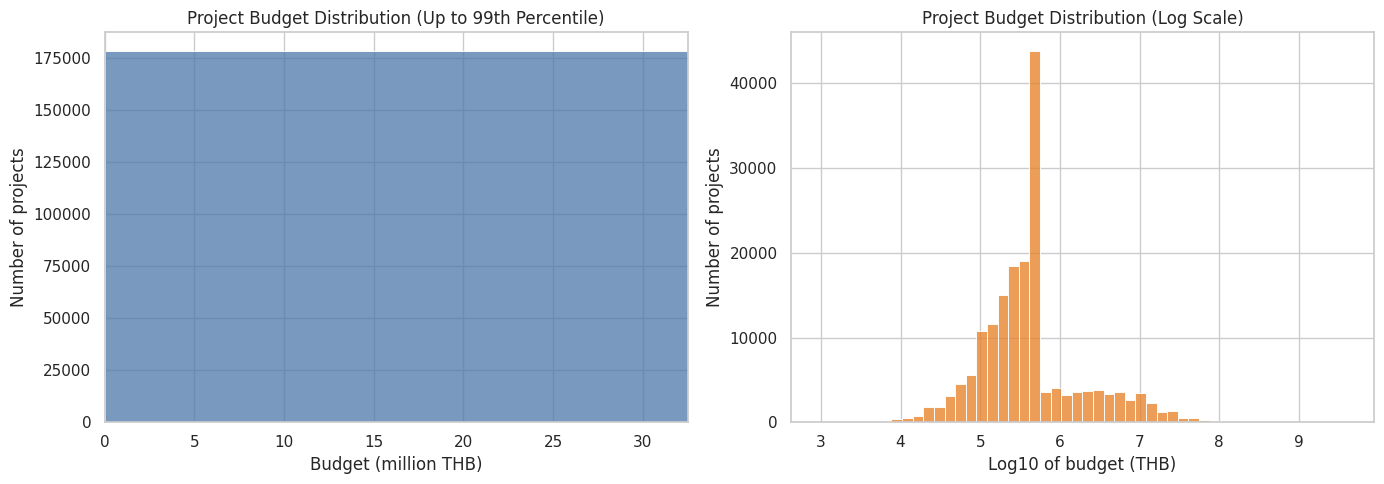

In [ ]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5)
)

sns.histplot(
    data=project_data,
    x='budget_million',
    bins=50,
    ax=axes[0],
    color='#4C78A8'
)

axes[0].set_xlim(
    0,
    budget_p99
)

axes[0].set_title(
    'Project Budget Distribution '
    '(Up to 99th Percentile)'
)

axes[0].set_xlabel(
    'Budget (million THB)'
)

axes[0].set_ylabel(
    'Number of projects'
)

sns.histplot(
    data=project_data,
    x='log10_budget',
    bins=50,
    ax=axes[1],
    color='#E67E22'
)

axes[1].set_title(
    'Project Budget Distribution '
    '(Log Scale)'
)

axes[1].set_xlabel(
    'Log10 of budget (THB)'
)

axes[1].set_ylabel(
    'Number of projects'
)

plt.tight_layout()
plt.show()

In [ ]:
common_budget_values = (
    project_data[budget_column]
    .value_counts()
    .head(15)
    .rename_axis('budget')
    .reset_index(name='project_count')
)

common_budget_values['budget_million'] = (
    common_budget_values['budget']
    .div(1_000_000)
)

common_budget_values['project_pct'] = (
    common_budget_values['project_count']
    .div(len(project_data))
    .mul(100)
)

display(
    common_budget_values[
        [
            'budget',
            'budget_million',
            'project_count',
            'project_pct'
        ]
    ]
)

,budget,budget_million,project_count,project_pct
0,"500,000.00",0.50,6523,3.64
1,"499,000.00",0.50,3593,2.01
2,"200,000.00",0.20,2527,1.41
3,"498,000.00",0.50,2438,1.36
4,"300,000.00",0.30,2266,1.27
5,"100,000.00",0.10,1991,1.11
6,"490,000.00",0.49,1790,1.00
7,"150,000.00",0.15,1527,0.85
8,"495,000.00",0.49,1525,0.85
9,"400,000.00",0.40,1481,0.83


Budget Distribution Findings

วงเงินงบประมาณของโครงการจ้างก่อสร้างมีการกระจายแบบเบ้ขวา
อย่างชัดเจน โดย 76.34% ของโครงการมีวงเงินไม่เกิน 500,000 บาท
ขณะที่ 99% มีวงเงินไม่เกิน 32.50 ล้านบาท แต่ยังมีโครงการ
มูลค่าสูงมากบางรายการซึ่งทำให้ค่าเฉลี่ยสูงกว่าค่ามัธยฐานมาก

นอกจากนี้ พบว่าวงเงินที่ปรากฏบ่อยที่สุดคือ 500,000 บาท
จำนวน 6,523 โครงการ และพบโครงการจำนวนมากที่มีวงเงิน
ใกล้เคียงแต่ต่ำกว่า 500,000 บาท เช่น 499,000, 498,000,
497,000, 496,000, 495,000 และ 490,000 บาท

รูปแบบดังกล่าวแสดงถึงการกระจุกตัวของวงเงินบริเวณ 500,000 บาท
แต่ยังไม่สามารถอธิบายสาเหตุได้จากข้อมูลชุดนี้เพียงอย่างเดียว
จึงควรนำไปเปรียบเทียบกับวิธีจัดซื้อ หน่วยงาน และลักษณะโครงการ
ในขั้นต่อไป

In [ ]:
budget_bins = [
    0,
    100_000,
    200_000,
    300_000,
    400_000,
    500_000,
    1_000_000,
    5_000_000,
    10_000_000,
    50_000_000,
    np.inf
]

budget_labels = [
    '≤100K',
    '100K–200K',
    '200K–300K',
    '300K–400K',
    '400K–500K',
    '500K–1M',
    '1M–5M',
    '5M–10M',
    '10M–50M',
    '>50M'
]

project_data['budget_band'] = pd.cut(
    project_data[budget_column],
    bins=budget_bins,
    labels=budget_labels,
    include_lowest=True,
    right=True
)

budget_band_summary = (
    project_data['budget_band']
    .value_counts(sort=False)
    .rename('project_count')
    .reset_index()
)

budget_band_summary['project_pct'] = (
    budget_band_summary['project_count']
    .div(len(project_data))
    .mul(100)
)

display(budget_band_summary)

,budget_band,project_count,project_pct
0,≤100K,23393,13.07
1,100K–200K,27835,15.55
2,200K–300K,22675,12.67
3,300K–400K,17815,9.95
4,400K–500K,44905,25.09
5,500K–1M,8171,4.57
6,1M–5M,18981,10.61
7,5M–10M,7899,4.41
8,10M–50M,6421,3.59
9,>50M,883,0.49


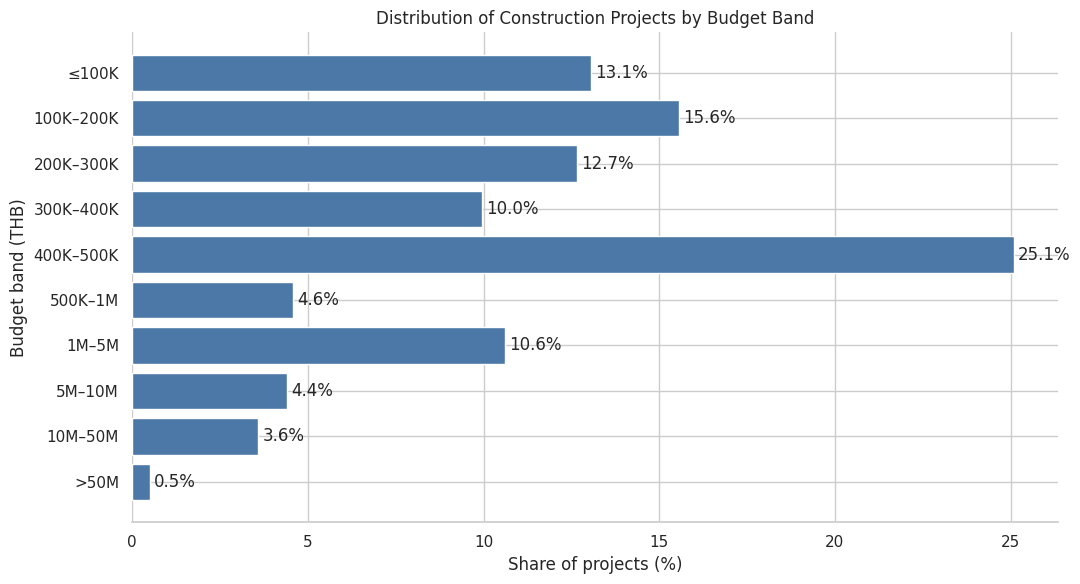

In [ ]:
fig, ax = plt.subplots(
    figsize=(11, 6)
)

bars = ax.barh(
    budget_band_summary['budget_band'],
    budget_band_summary['project_pct'],
    color='#4C78A8'
)

ax.bar_label(
    bars,
    labels=[
        f'{value:.1f}%'
        for value
        in budget_band_summary['project_pct']
    ],
    padding=3
)

ax.invert_yaxis()

ax.set_title(
    'Distribution of Construction Projects '
    'by Budget Band'
)

ax.set_xlabel('Share of projects (%)')
ax.set_ylabel('Budget band (THB)')

ax.spines[
    ['top', 'right', 'left']
].set_visible(False)

plt.tight_layout()
plt.show()

Budget Band Findings

โครงการจำนวน 76.34% มีวงเงินงบประมาณไม่เกิน 500,000 บาท
โดยช่วง 400,000–500,000 บาทเป็นกลุ่มที่มีจำนวนมากที่สุด
คิดเป็น 25.09% ของโครงการทั้งหมด

เมื่อวงเงินสูงกว่า 500,000 บาท สัดส่วนลดลงเหลือเพียง 4.57%
ในช่วง 500,000–1 ล้านบาท ขณะที่โครงการมูลค่าเกิน 50 ล้านบาท
มีเพียง 0.49%

ผลนี้แสดงให้เห็นว่าการพิจารณาเฉพาะจำนวนโครงการอาจทำให้
โครงการขนาดเล็กมีอิทธิพลต่อภาพรวมมากเกินไป ในการวิเคราะห์
ขั้นต่อไปจึงควรพิจารณาทั้งจำนวนโครงการและมูลค่ารวมควบคู่กัน

การกระจุกตัวของวงเงินบริเวณ 500,000 บาทเป็นประเด็นที่น่าสนใจ
สำหรับการวิเคราะห์ร่วมกับวิธีจัดซื้อ แต่ยังไม่สามารถสรุปสาเหตุ
หรือระบุว่าเป็นความผิดปกติได้จากการกระจายของวงเงินเพียงอย่างเดียว

### 3.2 Budget, Reference Price, and Awarded Price

ส่วนนี้เปรียบเทียบราคาที่ตกลงกับวงเงินงบประมาณและราคากลาง
เพื่อดูว่าค่าทั้งสามเคลื่อนไหวสอดคล้องกันเพียงใด และมีโครงการ
ที่อยู่เหนือหรือต่ำกว่าเส้นราคาเท่ากันในลักษณะใด

เนื่องจากข้อมูลมีจำนวนมากและมูลค่ามีช่วงกว้าง จึงสุ่มข้อมูล
10,000 โครงการสำหรับการแสดง scatter plot และใช้ log scale
เพื่อให้มองเห็นทั้งโครงการขนาดเล็กและขนาดใหญ่ได้ในภาพเดียว

การสุ่มใช้ `random_state=42` เพื่อให้ได้ตัวอย่างเดิมเมื่อรันซ้ำ
ส่วนการคำนวณสถิติยังคงใช้ข้อมูลทุกโครงการ

In [ ]:
price_plot_data = (
    project_data
    .loc[
        project_data[
            reference_price_column
        ].notna()
    ]
    .sample(
        n=min(
            10_000,
            project_data[
                reference_price_column
            ].notna().sum()
        ),
        random_state=42
    )
)

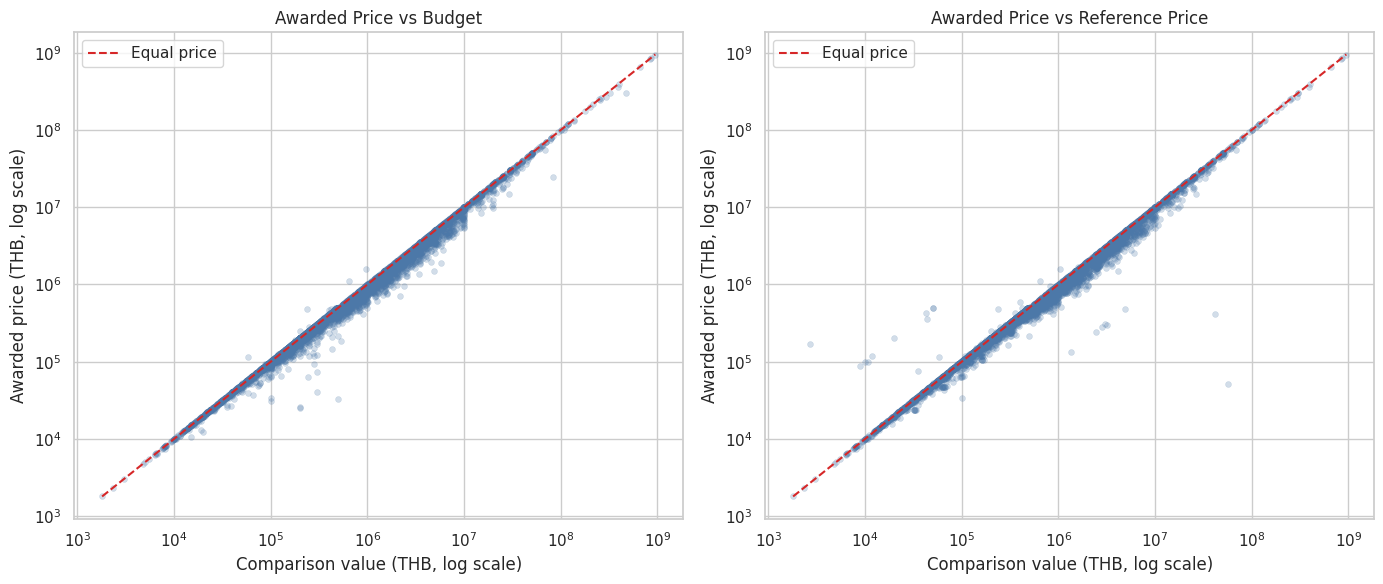

In [ ]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 6)
)

comparisons = [
    (
        budget_column,
        'Awarded Price vs Budget'
    ),
    (
        reference_price_column,
        'Awarded Price vs Reference Price'
    )
]

for ax, (x_column, title) in zip(
    axes,
    comparisons
):
    sns.scatterplot(
        data=price_plot_data,
        x=x_column,
        y=awarded_price_column,
        alpha=0.25,
        s=18,
        color='#4C78A8',
        edgecolor=None,
        ax=ax
    )

    lower_limit = min(
        price_plot_data[x_column].min(),
        price_plot_data[
            awarded_price_column
        ].min()
    )

    upper_limit = max(
        price_plot_data[x_column].max(),
        price_plot_data[
            awarded_price_column
        ].max()
    )

    ax.plot(
        [lower_limit, upper_limit],
        [lower_limit, upper_limit],
        linestyle='--',
        color='#D62728',
        linewidth=1.5,
        label='Equal price'
    )

    ax.set_xscale('log')
    ax.set_yscale('log')

    ax.set_title(title)
    ax.set_xlabel('Comparison value (THB, log scale)')
    ax.set_ylabel('Awarded price (THB, log scale)')
    ax.legend()

plt.tight_layout()
plt.show()

Price Relationship Findings

ราคาที่ตกลงมีความสัมพันธ์เชิงบวกอย่างชัดเจนกับทั้งวงเงินงบประมาณ
และราคากลาง โดยจุดส่วนใหญ่อยู่ใกล้เส้นราคาเท่ากันหรืออยู่ใต้เส้น
แสดงว่าราคาที่ตกลงมักไม่สูงกว่ากรอบราคาที่ใช้เปรียบเทียบ

การเปรียบเทียบกับราคากลางมีจุดที่อยู่ห่างจากเส้นราคาเท่ากัน
มากกว่าการเปรียบเทียบกับวงเงินงบประมาณ โดยพบทั้งกรณีที่ราคา
ตกลงต่ำกว่าราคากลางมาก และกรณีที่ราคาตกลงสูงกว่าราคากลาง
บางรายการ

กราฟนี้ใช้ข้อมูลตัวอย่าง 10,000 โครงการเพื่อการแสดงผลเท่านั้น
จึงใช้สำหรับมองรูปแบบโดยรวม ไม่ใช้ตัดสินจำนวนหรือสัดส่วน
ของโครงการที่ผิดสังเกต

### 3.3 Comparison by Procurement Method

วิธีจัดซื้ออาจสัมพันธ์กับขนาดโครงการและระดับส่วนต่างราคา
ส่วนนี้จึงเปรียบเทียบจำนวนโครงการ มูลค่า และส่วนต่างราคา
ระหว่างวิธีจัดซื้อทั้ง 4 วิธี

เนื่องจากส่วนต่างร้อยละมีค่าผิดสังเกตรุนแรง การเปรียบเทียบ
ค่ากลางจะใช้ median แทน mean

In [ ]:
method_column = (
    'ชื่อวิธีการจัดซื้อจัดจ้าง'
)

method_analysis = (
    project_data
    .assign(
        awarded_above_budget=(
            project_data[
                awarded_price_column
            ]
            .gt(
                project_data[
                    budget_column
                ]
            )
        ),
        awarded_equal_budget=(
            project_data[
                awarded_price_column
            ]
            .eq(
                project_data[
                    budget_column
                ]
            )
        ),
        reference_available=(
            project_data[
                reference_price_column
            ]
            .notna()
        ),
        awarded_above_reference=(
            project_data[
                awarded_price_column
            ]
            .gt(
                project_data[
                    reference_price_column
                ]
            )
        ),
        awarded_equal_reference=(
            project_data[
                awarded_price_column
            ]
            .eq(
                project_data[
                    reference_price_column
                ]
            )
        )
    )
    .groupby(method_column)
    .agg(
        project_count=(
            'รหัสโครงการ',
            'size'
        ),
        total_budget=(
            budget_column,
            'sum'
        ),
        median_budget=(
            budget_column,
            'median'
        ),
        median_budget_saving_pct=(
            'budget_saving_pct',
            'median'
        ),
        median_reference_discount_pct=(
            'reference_discount_pct',
            'median'
        ),
        above_budget_count=(
            'awarded_above_budget',
            'sum'
        ),
        equal_budget_count=(
            'awarded_equal_budget',
            'sum'
        ),
        reference_available_count=(
            'reference_available',
            'sum'
        ),
        above_reference_count=(
            'awarded_above_reference',
            'sum'
        ),
        equal_reference_count=(
            'awarded_equal_reference',
            'sum'
        )
    )
    .reset_index()
)

method_analysis['project_pct'] = (
    method_analysis['project_count']
    .div(
        method_analysis[
            'project_count'
        ].sum()
    )
    .mul(100)
)

method_analysis['budget_share_pct'] = (
    method_analysis['total_budget']
    .div(
        method_analysis[
            'total_budget'
        ].sum()
    )
    .mul(100)
)

method_analysis['above_budget_pct'] = (
    method_analysis['above_budget_count']
    .div(
        method_analysis[
            'project_count'
        ]
    )
    .mul(100)
)

method_analysis['equal_budget_pct'] = (
    method_analysis['equal_budget_count']
    .div(
        method_analysis[
            'project_count'
        ]
    )
    .mul(100)
)

method_analysis['above_reference_pct'] = (
    method_analysis['above_reference_count']
    .div(
        method_analysis[
            'reference_available_count'
        ]
    )
    .mul(100)
)

method_analysis['equal_reference_pct'] = (
    method_analysis['equal_reference_count']
    .div(
        method_analysis[
            'reference_available_count'
        ]
    )
    .mul(100)
)

method_analysis = (
    method_analysis
    .sort_values(
        'project_count',
        ascending=False
    )
    .reset_index(drop=True)
)

In [ ]:
display(
    method_analysis[
        [
            method_column,
            'project_count',
            'project_pct',
            'budget_share_pct',
            'median_budget',
            'median_budget_saving_pct',
            'median_reference_discount_pct',
            'equal_budget_pct',
            'above_budget_pct',
            'equal_reference_pct',
            'above_reference_pct'
        ]
    ]
)

,ชื่อวิธีการจัดซื้อจัดจ้าง,project_count,project_pct,budget_share_pct,median_budget,median_budget_saving_pct,median_reference_discount_pct,equal_budget_pct,above_budget_pct,equal_reference_pct,above_reference_pct
0,เฉพาะเจาะจง,136651,76.35,9.33,"283,000.00",0.18,0.22,41.76,0.19,28.17,0.52
1,ประกวดราคาอิเล็กทรอนิกส์ (e-bidding),37973,21.22,83.34,"3,097,500.00",8.07,6.60,0.63,0.11,0.13,0.15
2,คัดเลือก,4352,2.43,7.33,"2,736,650.00",0.21,0.28,16.04,0.34,6.92,0.76
3,ตกลงราคา,2,0.00,0.00,"240,000.00",7.33,0.00,50.00,0.00,100.00,0.00


Procurement Method Findings

วิธีเฉพาะเจาะจงเป็นวิธีที่ใช้มากที่สุด คิดเป็น 76.35%
ของจำนวนโครงการทั้งหมด แต่มีสัดส่วนวงเงินรวมเพียง 9.33%
และมีวงเงินงบประมาณมัธยฐาน 283,000 บาท

ในทางตรงกันข้าม e-bidding มีจำนวนเพียง 21.22% ของโครงการ
แต่ครองวงเงินรวมถึง 83.34% และมีวงเงินงบประมาณมัธยฐาน
ประมาณ 3.10 ล้านบาท แสดงว่า e-bidding ถูกใช้กับโครงการ
ที่มีขนาดใหญ่กว่าโดยทั่วไป

ส่วนต่างราคายังแตกต่างกันอย่างชัดเจน โดย e-bidding มีส่วนต่าง
จากงบประมาณมัธยฐาน 8.07% และส่วนต่างจากราคากลางมัธยฐาน
6.60% ขณะที่วิธีเฉพาะเจาะจงมีค่ามัธยฐานเพียง 0.18%
และ 0.22% ตามลำดับ

นอกจากนี้ โครงการเฉพาะเจาะจง 41.76% มีราคาตกลงเท่ากับ
วงเงินงบประมาณ และ 28.17% มีราคาตกลงเท่ากับราคากลาง
จึงควรศึกษาต่อว่ารูปแบบดังกล่าวสัมพันธ์กับช่วงวงเงินหรือไม่

วิธีตกลงราคามีเพียง 2 โครงการ จึงไม่นำมาใช้สรุป
ความแตกต่างระหว่างวิธีจัดซื้อ

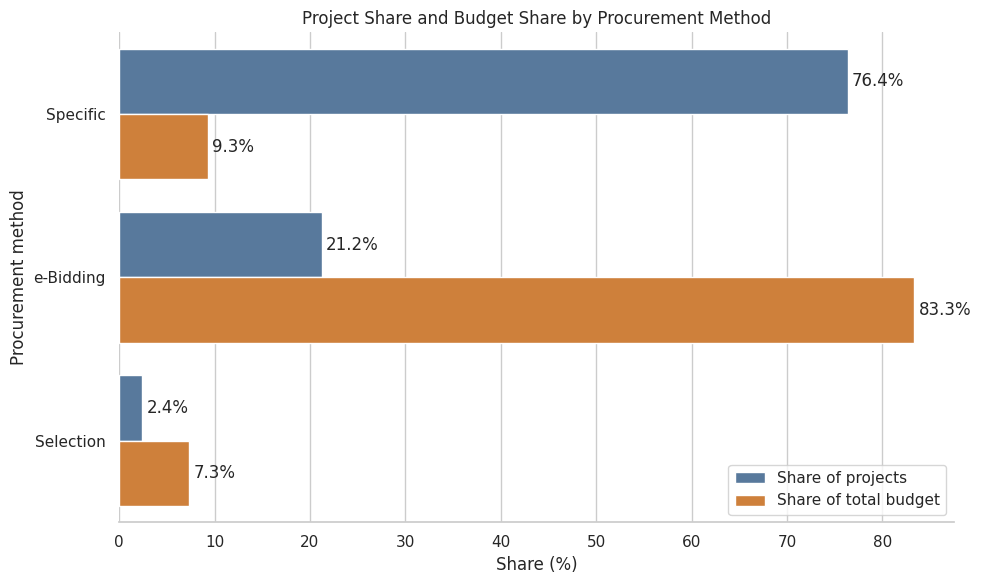

In [ ]:
method_label_map = {
    'เฉพาะเจาะจง': 'Specific',
    'ประกวดราคาอิเล็กทรอนิกส์ (e-bidding)': 'e-Bidding',
    'คัดเลือก': 'Selection',
    'ตกลงราคา': 'Price Agreement'
}

method_plot = (
    method_analysis
    .loc[
        method_analysis[
            'project_count'
        ].gt(2)
    ]
    .copy()
)

method_plot['procurement_method'] = (
    method_plot[method_column]
    .map(method_label_map)
)

method_plot = (
    method_plot[
        [
            'procurement_method',
            'project_pct',
            'budget_share_pct'
        ]
    ]
    .melt(
        id_vars='procurement_method',
        var_name='measure',
        value_name='percentage'
    )
)

measure_label_map = {
    'project_pct': 'Share of projects',
    'budget_share_pct': 'Share of total budget'
}

method_plot['measure'] = (
    method_plot['measure']
    .map(measure_label_map)
)

fig, ax = plt.subplots(
    figsize=(10, 6)
)

sns.barplot(
    data=method_plot,
    y='procurement_method',
    x='percentage',
    hue='measure',
    palette=[
        '#4C78A8',
        '#E67E22'
    ],
    ax=ax
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.1f%%',
        padding=3
    )

ax.set_title(
    'Project Share and Budget Share '
    'by Procurement Method'
)

ax.set_xlabel('Share (%)')
ax.set_ylabel('Procurement method')
ax.legend(title='')

ax.spines[
    ['top', 'right', 'left']
].set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:
budget_concentration = (
    project_data
    .assign(
        budget_le_500k=(
            project_data[
                budget_column
            ].le(500_000)
        ),
        budget_400k_to_500k=(
            project_data[
                budget_column
            ].gt(400_000)
            & project_data[
                budget_column
            ].le(500_000)
        ),
        budget_490k_to_500k=(
            project_data[
                budget_column
            ].ge(490_000)
            & project_data[
                budget_column
            ].le(500_000)
        ),
        budget_exactly_500k=(
            project_data[
                budget_column
            ].eq(500_000)
        )
    )
    .groupby(method_column)
    .agg(
        project_count=(
            'รหัสโครงการ',
            'size'
        ),
        budget_le_500k_count=(
            'budget_le_500k',
            'sum'
        ),
        budget_400k_to_500k_count=(
            'budget_400k_to_500k',
            'sum'
        ),
        budget_490k_to_500k_count=(
            'budget_490k_to_500k',
            'sum'
        ),
        budget_exactly_500k_count=(
            'budget_exactly_500k',
            'sum'
        )
    )
    .reset_index()
)

count_columns = [
    'budget_le_500k_count',
    'budget_400k_to_500k_count',
    'budget_490k_to_500k_count',
    'budget_exactly_500k_count'
]

for column in count_columns:
    percentage_column = (
        column
        .replace('_count', '_pct')
    )

    budget_concentration[
        percentage_column
    ] = (
        budget_concentration[column]
        .div(
            budget_concentration[
                'project_count'
            ]
        )
        .mul(100)
    )

display(
    budget_concentration[
        [
            method_column,
            'project_count',
            'budget_le_500k_pct',
            'budget_400k_to_500k_pct',
            'budget_490k_to_500k_pct',
            'budget_exactly_500k_pct'
        ]
    ]
)

,ชื่อวิธีการจัดซื้อจัดจ้าง,project_count,budget_le_500k_pct,budget_400k_to_500k_pct,budget_490k_to_500k_pct,budget_exactly_500k_pct
0,คัดเลือก,4352,2.25,0.51,0.11,0.02
1,ตกลงราคา,2,100.00,0.00,0.00,0.00
2,ประกวดราคาอิเล็กทรอนิกส์ (e-bidding),37973,1.19,0.46,0.21,0.10
3,เฉพาะเจาะจง,136651,99.57,32.72,19.14,4.75


Budget Concentration by Procurement Method

การกระจุกตัวของวงเงินบริเวณ 500,000 บาทเกิดขึ้นเด่นชัด
ในโครงการที่ใช้วิธีเฉพาะเจาะจง

โครงการเฉพาะเจาะจงจำนวน 99.57% มีวงเงินไม่เกิน 500,000 บาท
โดย 32.72% อยู่ในช่วงมากกว่า 400,000 ถึง 500,000 บาท
และ 19.14% อยู่ในช่วง 490,000–500,000 บาท นอกจากนี้
4.75% มีวงเงินเท่ากับ 500,000 บาทพอดี

ในทางตรงกันข้าม โครงการที่มีวงเงินไม่เกิน 500,000 บาท
พบเพียง 2.25% ในวิธีคัดเลือก และ 1.19% ใน e-bidding

ผลดังกล่าวแสดงว่าวิธีจัดซื้อมีความสัมพันธ์อย่างมากกับช่วงวงเงิน
และการกระจุกตัวใกล้ 500,000 บาทควรถูกนำไปวิเคราะห์เพิ่มเติม
อย่างไรก็ตาม ข้อมูลนี้ยังไม่เพียงพอที่จะสรุปว่าเกิดการแบ่งโครงการ
หรือการหลีกเลี่ยงกระบวนการจัดซื้อ

### 3.4 Analysis by Government Agency

ส่วนนี้เปรียบเทียบหน่วยงานในสองมิติ ได้แก่ จำนวนโครงการ
และวงเงินงบประมาณรวม เพื่อแยกหน่วยงานที่ดำเนินโครงการจำนวนมาก
ออกจากหน่วยงานที่รับผิดชอบโครงการมูลค่าสูง

การวิเคราะห์ใช้ `ชื่อหน่วยงาน` จากข้อมูลระดับโครงการ
และยังไม่รวม `ชื่อหน่วยงานย่อย`

In [ ]:
agency_column = 'ชื่อหน่วยงาน'

agency_summary = (
    project_data
    .groupby(agency_column)
    .agg(
        project_count=(
            'รหัสโครงการ',
            'size'
        ),
        total_budget=(
            budget_column,
            'sum'
        ),
        median_budget=(
            budget_column,
            'median'
        ),
        total_awarded_price=(
            awarded_price_column,
            'sum'
        ),
        median_budget_saving_pct=(
            'budget_saving_pct',
            'median'
        ),
        median_reference_discount_pct=(
            'reference_discount_pct',
            'median'
        )
    )
    .reset_index()
)

agency_summary['project_share_pct'] = (
    agency_summary['project_count']
    .div(
        agency_summary[
            'project_count'
        ].sum()
    )
    .mul(100)
)

agency_summary['budget_share_pct'] = (
    agency_summary['total_budget']
    .div(
        agency_summary[
            'total_budget'
        ].sum()
    )
    .mul(100)
)

agency_summary['total_budget_billion'] = (
    agency_summary['total_budget']
    .div(1_000_000_000)
)

In [ ]:
top_agencies_by_count = (
    agency_summary
    .nlargest(
        10,
        'project_count'
    )
    [
        [
            agency_column,
            'project_count',
            'project_share_pct',
            'total_budget_billion',
            'median_budget'
        ]
    ]
)

display(top_agencies_by_count)

,ชื่อหน่วยงาน,project_count,project_share_pct,total_budget_billion,median_budget
21,กรมทางหลวง,5774,3.23,95.33,"8,200,000.00"
22,กรมทางหลวงชนบท,5484,3.06,44.91,"2,800,000.00"
5,กรมการปกครอง,4461,2.49,3.35,"373,000.00"
35,กรมพัฒนาที่ดิน,3531,1.97,2.49,"189,600.00"
84,การไฟฟ้าส่วนภูมิภาค,3185,1.78,5.83,"219,613.22"
15,กรมชลประทาน,2414,1.35,38.03,"833,200.00"
76,การประปาส่วนภูมิภาค,2022,1.13,17.55,"395,968.00"
65,กรุงเทพมหานคร,997,0.56,13.07,"2,004,000.00"
75,การประปานครหลวง,934,0.52,4.38,"498,593.50"
64,กรมโยธาธิการและผังเมือง,780,0.44,32.31,"20,000,000.00"


In [ ]:
top_agencies_by_budget = (
    agency_summary
    .nlargest(
        10,
        'total_budget'
    )
    [
        [
            agency_column,
            'total_budget_billion',
            'budget_share_pct',
            'project_count',
            'median_budget',
            'median_budget_saving_pct',
            'median_reference_discount_pct'
        ]
    ]
)

display(top_agencies_by_budget)

,ชื่อหน่วยงาน,total_budget_billion,budget_share_pct,project_count,median_budget,median_budget_saving_pct,median_reference_discount_pct
21,กรมทางหลวง,95.33,20.03,5774,"8,200,000.00",0.55,0.11
22,กรมทางหลวงชนบท,44.91,9.44,5484,"2,800,000.00",0.08,0.20
15,กรมชลประทาน,38.03,7.99,2414,"833,200.00",0.47,0.88
64,กรมโยธาธิการและผังเมือง,32.31,6.79,780,"20,000,000.00",1.00,0.91
76,การประปาส่วนภูมิภาค,17.55,3.69,2022,"395,968.00",0.97,0.21
65,กรุงเทพมหานคร,13.07,2.75,997,"2,004,000.00",7.24,5.82
82,การไฟฟ้านครหลวง,9.40,1.98,86,"1,622,500.00",13.82,0.76
656,สำนักงานตำรวจแห่งชาติ,6.70,1.41,449,"8,394,600.00",2.06,3.36
19,กรมทรัพยากรน้ำ,6.28,1.32,286,"13,250,000.00",0.59,0.23
20,กรมทรัพยากรน้ำบาดาล,6.15,1.29,77,"5,147,800.00",0.21,0.15


**Government Agency Findings**

กรมทางหลวงมีจำนวนโครงการมากที่สุด 5,774 โครงการ และมีวงเงินรวม
สูงที่สุดประมาณ 95.33 พันล้านบาท หรือ 20.03% ของวงเงินทั้งหมด
จึงเป็นหน่วยงานที่มีบทบาทสูงทั้งด้านจำนวนและมูลค่าโครงการ

กรมทางหลวงชนบทและกรมชลประทานอยู่ในอันดับสูงทั้งสองมิติเช่นกัน
ขณะที่กรมโยธาธิการและผังเมืองมีเพียง 780 โครงการ แต่มีวงเงินรวม
สูงถึง 32.31 พันล้านบาท และมีวงเงินมัธยฐาน 20 ล้านบาท
สะท้อนว่าเป็นหน่วยงานที่มีโครงการขนาดใหญ่โดยทั่วไป

ในทางตรงกันข้าม กรมการปกครองและกรมพัฒนาที่ดินมีจำนวนโครงการ
มากเป็นอันดับต้น แต่มีวงเงินมัธยฐานเพียง 373,000 และ 189,600 บาท
ตามลำดับ แสดงให้เห็นว่าการจัดอันดับจากจำนวนโครงการและวงเงินรวม
ให้ภาพที่แตกต่างกัน

หน่วยงาน 4 อันดับแรกตามวงเงินรวมครองวงเงินประมาณ 44.25%
ของข้อมูลทั้งหมด โดยส่วนใหญ่เป็นหน่วยงานที่รับผิดชอบ
โครงสร้างพื้นฐานด้านถนน น้ำ และงานโยธา

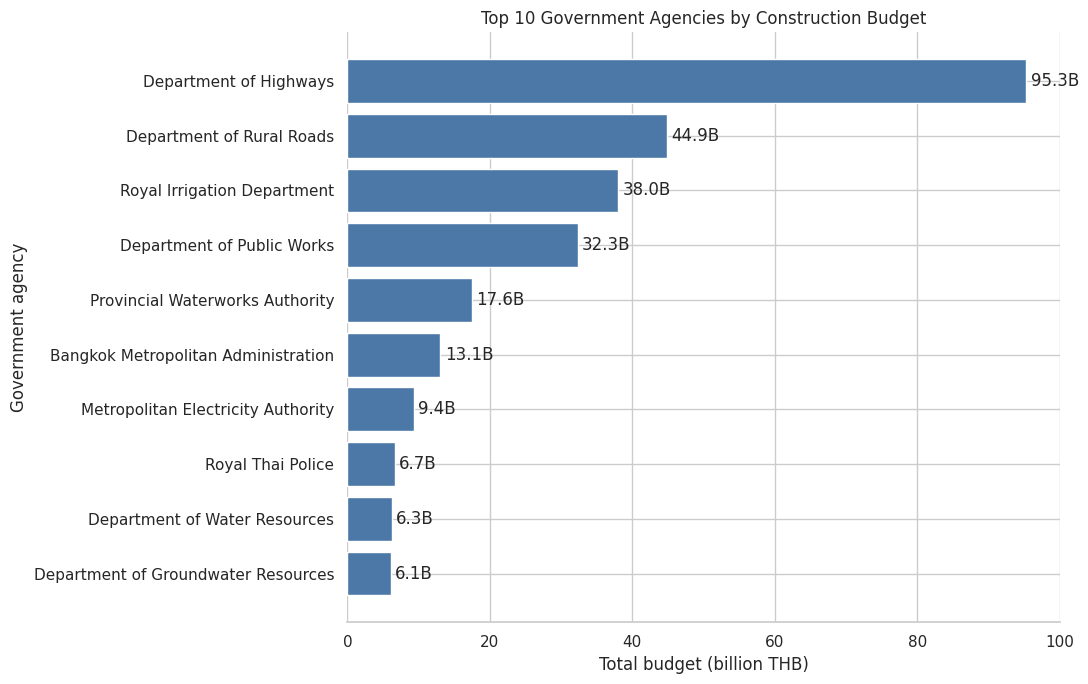

In [ ]:
agency_label_map = {
    'กรมทางหลวง': 'Department of Highways',
    'กรมทางหลวงชนบท': 'Department of Rural Roads',
    'กรมชลประทาน': 'Royal Irrigation Department',
    'กรมโยธาธิการและผังเมือง': (
        'Department of Public Works'
    ),
    'การประปาส่วนภูมิภาค': (
        'Provincial Waterworks Authority'
    ),
    'กรุงเทพมหานคร': (
        'Bangkok Metropolitan Administration'
    ),
    'การไฟฟ้านครหลวง': (
        'Metropolitan Electricity Authority'
    ),
    'สำนักงานตำรวจแห่งชาติ': (
        'Royal Thai Police'
    ),
    'กรมทรัพยากรน้ำ': (
        'Department of Water Resources'
    ),
    'กรมทรัพยากรน้ำบาดาล': (
        'Department of Groundwater Resources'
    )
}

agency_budget_plot = (
    agency_summary
    .nlargest(
        10,
        'total_budget'
    )
    .sort_values(
        'total_budget_billion',
        ascending=True
    )
    .copy()
)

agency_budget_plot['agency_label'] = (
    agency_budget_plot[agency_column]
    .map(agency_label_map)
)

fig, ax = plt.subplots(
    figsize=(11, 7)
)

bars = ax.barh(
    agency_budget_plot['agency_label'],
    agency_budget_plot[
        'total_budget_billion'
    ],
    color='#4C78A8'
)

ax.bar_label(
    bars,
    labels=[
        f'{budget:.1f}B'
        for budget
        in agency_budget_plot[
            'total_budget_billion'
        ]
    ],
    padding=3
)

ax.set_title(
    'Top 10 Government Agencies '
    'by Construction Budget'
)

ax.set_xlabel('Total budget (billion THB)')
ax.set_ylabel('Government agency')

ax.spines[
    ['top', 'right', 'left']
].set_visible(False)

plt.tight_layout()
plt.show()

### 3.5 Geographic Distribution

ส่วนนี้เปรียบเทียบจำนวนโครงการและวงเงินรวมในแต่ละจังหวัด
เพื่อดูว่าพื้นที่ที่มีโครงการจำนวนมากเป็นพื้นที่เดียวกับ
พื้นที่ที่ได้รับวงเงินรวมสูงหรือไม่

ข้อมูลจังหวัดระบุสถานที่ของโครงการตามชุดข้อมูลต้นทาง
จึงไม่ได้หมายถึงที่ตั้งสำนักงานใหญ่ของหน่วยงานหรือผู้รับจ้าง

In [ ]:
province_column = 'จังหวัด'

province_summary = (
    project_data
    .groupby(province_column)
    .agg(
        project_count=(
            'รหัสโครงการ',
            'size'
        ),
        total_budget=(
            budget_column,
            'sum'
        ),
        median_budget=(
            budget_column,
            'median'
        ),
        total_awarded_price=(
            awarded_price_column,
            'sum'
        ),
        median_budget_saving_pct=(
            'budget_saving_pct',
            'median'
        ),
        median_reference_discount_pct=(
            'reference_discount_pct',
            'median'
        )
    )
    .reset_index()
)

province_summary['project_share_pct'] = (
    province_summary['project_count']
    .div(
        province_summary[
            'project_count'
        ].sum()
    )
    .mul(100)
)

province_summary['budget_share_pct'] = (
    province_summary['total_budget']
    .div(
        province_summary[
            'total_budget'
        ].sum()
    )
    .mul(100)
)

province_summary['total_budget_billion'] = (
    province_summary['total_budget']
    .div(1_000_000_000)
)

In [ ]:
display(
    province_summary
    .nlargest(
        10,
        'project_count'
    )
    [
        [
            province_column,
            'project_count',
            'project_share_pct',
            'total_budget_billion',
            'median_budget'
        ]
    ]
)

,จังหวัด,project_count,project_share_pct,total_budget_billion,median_budget
18,นครราชสีมา,8641,4.83,15.30,"362,000.00"
68,อุบลราชธานี,7181,4.01,8.56,"321,800.00"
5,ขอนแก่น,6605,3.69,10.60,"400,000.00"
71,เชียงใหม่,5894,3.29,11.35,"350,000.00"
65,อุดรธานี,5619,3.14,7.26,"330,000.00"
48,ศรีสะเกษ,5328,2.98,5.67,"308,750.00"
1,กรุงเทพมหานคร,4825,2.70,177.54,"4,460,000.00"
25,บุรีรัมย์,4675,2.61,5.37,"330,000.00"
60,สุรินทร์,4285,2.39,4.45,"358,000.00"
70,เชียงราย,4121,2.30,5.02,"341,400.00"


In [ ]:
display(
    province_summary
    .nlargest(
        10,
        'total_budget'
    )
    [
        [
            province_column,
            'total_budget_billion',
            'budget_share_pct',
            'project_count',
            'median_budget',
            'median_budget_saving_pct',
            'median_reference_discount_pct'
        ]
    ]
)

,จังหวัด,total_budget_billion,budget_share_pct,project_count,median_budget,median_budget_saving_pct,median_reference_discount_pct
1,กรุงเทพมหานคร,177.54,37.30,4825,"4,460,000.00",1.24,0.80
18,นครราชสีมา,15.30,3.22,8641,"362,000.00",0.60,0.57
8,ชลบุรี,11.82,2.48,2854,"495,000.00",1.31,0.45
71,เชียงใหม่,11.35,2.38,5894,"350,000.00",0.50,0.56
5,ขอนแก่น,10.60,2.23,6605,"400,000.00",0.35,0.38
50,สงขลา,10.15,2.13,2641,"499,000.00",0.30,0.29
68,อุบลราชธานี,8.56,1.80,7181,"321,800.00",0.34,0.31
21,นนทบุรี,8.09,1.70,709,"671,498.83",4.36,3.00
19,นครศรีธรรมราช,7.42,1.56,3782,"448,000.00",0.34,0.51
65,อุดรธานี,7.26,1.53,5619,"330,000.00",0.20,0.23


**Geographic Findings**

นครราชสีมามีจำนวนโครงการมากที่สุด 8,641 โครงการ
รองลงมาคืออุบลราชธานี 7,181 โครงการ และขอนแก่น
6,605 โครงการ โดยจังหวัดที่มีโครงการจำนวนมากส่วนใหญ่
มีวงเงินมัธยฐานประมาณ 300,000–400,000 บาท

กรุงเทพมหานครมีจำนวน 4,825 โครงการ หรือ 2.70%
ของโครงการทั้งหมด แต่มีวงเงินรวมสูงถึง 177.54 พันล้านบาท
คิดเป็น 37.30% ของวงเงินทั้งหมด และมีวงเงินมัธยฐาน
4.46 ล้านบาท

ผลนี้แสดงว่าจังหวัดที่มีจำนวนโครงการมากที่สุดไม่จำเป็นต้องเป็น
จังหวัดที่มีวงเงินรวมสูงที่สุด โดยกรุงเทพมหานครมีโครงการ
ขนาดใหญ่กว่าจังหวัดอื่นโดยทั่วไป

การวิเคราะห์พื้นที่จะใช้เป็นบริบทประกอบการอธิบายข้อมูล
แต่จะไม่เป็นแกนหลักของการค้นหา Red Flag ในโครงการนี้

### 3.6 Supplier Data Understanding

การวิเคราะห์ผู้รับจ้างจะใช้ข้อมูลทุกแถวจาก `construction_data`
เนื่องจากโครงการหนึ่งอาจมีหลายสัญญา หลายผู้ชนะ หรือสมาชิก
กิจการร่วมค้า

ก่อนสรุปจำนวนโครงการและมูลค่าตามผู้รับจ้าง จะตรวจสอบว่า
เลขประจำตัวนิติบุคคลสามารถใช้ระบุผู้รับจ้างได้เพียงใด
และมีค่า placeholder หรือความสัมพันธ์แบบหนึ่งรหัสหลายชื่อหรือไม่

In [ ]:
supplier_id_column = (
    'เลขประจำตัวนิติบุคคล 13 หลัก'
)

supplier_name_column = (
    'ชื่อผู้ชนะการเสนอราคา'
)

print('Most frequent supplier IDs:')

display(
    construction_data[
        supplier_id_column
    ]
    .value_counts(
        dropna=False
    )
    .head(15)
)

print('\nMost frequent supplier names:')

display(
    construction_data[
        supplier_name_column
    ]
    .value_counts(
        dropna=False
    )
    .head(15)
)

Most frequent supplier IDs:


,count
เลขประจำตัวนิติบุคคล 13 หลัก,
0523546000132,575
0405530000254,314
0365557000060,294
0523543000263,278
0483540000441,258
0333541000381,244
0363553000331,238
0523551000579,214
0463536000181,204



Most frequent supplier names:


,count
ชื่อผู้ชนะการเสนอราคา,
ห้างหุ้นส่วนจำกัด ตั้นอ้าย วิศวกรรม,575
บริษัท ชัยศิริคอนกรีต จำกัด,310
บริษัท ภูเขียวนครคอนกรีต จำกัด,294
ห้างหุ้นส่วนจำกัด สินทวีเคหะกิจ,278
ห้างหุ้นส่วนจำกัด บัญชาศรีสงครามก่อสร้าง,258
ห้างหุ้นส่วนจำกัด อึ้งเกี่ยอู๋,244
ห้างหุ้นส่วนจำกัด ด.โชคชัยโยธา,238
ห้างหุ้นส่วนจำกัด ลำปาง ภาณุภัทร์ก่อสร้าง 2008,212
ห้างหุ้นส่วนจำกัด ทรงวัฒนะคอนกรีต,204


In [ ]:
supplier_id_profile = (
    construction_data
    .groupby(supplier_id_column)
    [supplier_name_column]
    .nunique()
)

supplier_name_profile = (
    construction_data
    .groupby(supplier_name_column)
    [supplier_id_column]
    .nunique()
)

supplier_relationship_summary = pd.Series({
    'Unique supplier IDs': (
        construction_data[
            supplier_id_column
        ].nunique()
    ),
    'Unique supplier names': (
        construction_data[
            supplier_name_column
        ].nunique()
    ),
    'Supplier IDs linked to multiple names': (
        supplier_id_profile.gt(1).sum()
    ),
    'Supplier names linked to multiple IDs': (
        supplier_name_profile.gt(1).sum()
    )
})

display(
    supplier_relationship_summary
    .to_frame(name='value')
)

,value
Unique supplier IDs,33685
Unique supplier names,38826
Supplier IDs linked to multiple names,4234
Supplier names linked to multiple IDs,253


**Supplier Identifier Findings**

ข้อมูลมีเลขประจำตัวนิติบุคคลที่ไม่ซ้ำ 33,685 ค่า
และชื่อผู้ชนะการเสนอราคาที่ไม่ซ้ำ 38,826 ค่า

พบเลขนิติบุคคล 4,234 รหัสที่เชื่อมโยงกับชื่อผู้ชนะมากกว่าหนึ่งรูปแบบ
ซึ่งอาจเกิดจากความแตกต่างของการสะกด คำนำหน้า สาขา
หรือรูปแบบการบันทึกชื่อ ขณะเดียวกันพบชื่อผู้ชนะ 253 ชื่อ
ที่เชื่อมโยงกับเลขนิติบุคคลมากกว่าหนึ่งรหัส

ดังนั้น การวิเคราะห์ผู้รับจ้างจะใช้เลขประจำตัวนิติบุคคลเป็นรหัสหลัก
และใช้ชื่อที่พบบ่อยที่สุดของแต่ละรหัสเป็นชื่อสำหรับแสดงผล
โดยจะไม่รวมผู้รับจ้างจากชื่อเพียงอย่างเดียว

In [ ]:
project_awarded_total = (
    project_data[
        awarded_price_column
    ].sum()
)

contract_budget_total = (
    construction_data[
        'วงเงินงบประมาณในสัญญา (บาท)'
    ].sum()
)

value_difference = (
    contract_budget_total
    - project_awarded_total
)

value_difference_pct = (
    value_difference
    / project_awarded_total
    * 100
)

value_reconciliation = pd.Series({
    'Project awarded total': (
        project_awarded_total
    ),
    'Contract budget total': (
        contract_budget_total
    ),
    'Difference': (
        value_difference
    ),
    'Difference pct': (
        value_difference_pct
    ),
    'Missing contract budget rows': (
        construction_data[
            'วงเงินงบประมาณในสัญญา (บาท)'
        ]
        .isna()
        .sum()
    )
})

display(
    value_reconciliation
    .to_frame(name='value')
)

,value
Project awarded total,"450,676,863,445.93"
Contract budget total,"463,911,809,538.91"
Difference,"13,234,946,092.98"
Difference pct,2.94
Missing contract budget rows,90.00


In [ ]:
contract_value_by_project = (
    construction_data
    .groupby('รหัสโครงการ')
    [
        'วงเงินงบประมาณในสัญญา (บาท)'
    ]
    .sum(
        min_count=1
    )
    .rename('contract_budget_sum')
)

project_value_check = (
    project_data
    [
        [
            'รหัสโครงการ',
            awarded_price_column
        ]
    ]
    .merge(
        contract_value_by_project,
        on='รหัสโครงการ',
        how='left'
    )
)

project_value_check['difference'] = (
    project_value_check[
        'contract_budget_sum'
    ]
    - project_value_check[
        awarded_price_column
    ]
)

project_value_check['is_matched'] = np.isclose(
    project_value_check[
        'contract_budget_sum'
    ],
    project_value_check[
        awarded_price_column
    ],
    rtol=0,
    atol=1
)

project_reconciliation_summary = pd.Series({
    'Projects checked': (
        len(project_value_check)
    ),
    'Matched projects': (
        project_value_check[
            'is_matched'
        ].sum()
    ),
    'Unmatched projects': (
        ~project_value_check[
            'is_matched'
        ]
    ).sum(),
    'Matched pct': (
        project_value_check[
            'is_matched'
        ].mean()
        * 100
    )
})

display(
    project_reconciliation_summary
    .to_frame(name='value')
)

,value
Projects checked,"178,978.00"
Matched projects,"178,616.00"
Unmatched projects,362.00
Matched pct,99.80


**Contract Value Reconciliation**

ยอดรวมวงเงินระดับสัญญาตรงกับราคาตกลงระดับโครงการจำนวน
178,616 จาก 178,978 โครงการ หรือ 99.80%

มีโครงการที่ยอดไม่ตรงกัน 362 โครงการ และพบวงเงินระดับสัญญา
เป็นค่าว่าง 90 แถว แม้โครงการกลุ่มนี้มีจำนวนเพียง 0.20%
แต่ทำให้ยอดรวมระดับสัญญาสูงกว่าราคาตกลงระดับโครงการ
ประมาณ 13.23 พันล้านบาท หรือ 2.94%

ดังนั้น การวิเคราะห์มูลค่าตามผู้รับจ้างจะใช้เฉพาะโครงการ
ที่ผ่านการ Reconciliation เพื่อป้องกันการรวมมูลค่าซ้ำหรือ
ใช้ข้อมูลสัญญาที่ไม่สอดคล้องกัน

ส่วนโครงการที่ Reconciliation ไม่ผ่านจะไม่ถูกลบจากข้อมูลต้นทาง
และจะถูกเก็บไว้เป็น Candidate Data-quality Red Flag
สำหรับการตรวจสอบใน Notebook 03

In [ ]:
matched_project_ids = set(
    project_value_check.loc[
        project_value_check[
            'is_matched'
        ],
        'รหัสโครงการ'
    ]
)

supplier_value_data = (
    construction_data
    .loc[
        construction_data[
            'รหัสโครงการ'
        ].isin(
            matched_project_ids
        )
        & construction_data[
            'วงเงินงบประมาณในสัญญา (บาท)'
        ].notna()
    ]
    .copy()
)

print(
    f'Supplier value rows: '
    f'{len(supplier_value_data):,}'
)

print(
    f'Reconciled projects: '
    f'{supplier_value_data["รหัสโครงการ"].nunique():,}'
)

Supplier value rows: 178,985
Reconciled projects: 178,616


In [ ]:
supplier_name_lookup = (
    construction_data
    .groupby(
        [
            supplier_id_column,
            supplier_name_column
        ]
    )
    .size()
    .rename('name_count')
    .reset_index()
    .sort_values(
        [
            supplier_id_column,
            'name_count',
            supplier_name_column
        ],
        ascending=[
            True,
            False,
            True
        ]
    )
    .drop_duplicates(
        subset=supplier_id_column,
        keep='first'
    )
    [
        [
            supplier_id_column,
            supplier_name_column
        ]
    ]
    .rename(
        columns={
            supplier_name_column:
            'supplier_display_name'
        }
    )
)

In [ ]:
supplier_project_summary = (
    construction_data
    .groupby(supplier_id_column)
    .agg(
        supplier_project_count=(
            'รหัสโครงการ',
            'nunique'
        ),
        supplier_record_count=(
            'รหัสโครงการ',
            'size'
        )
    )
    .reset_index()
)

supplier_value_summary = (
    supplier_value_data
    .groupby(supplier_id_column)
    .agg(
        total_contract_value=(
            'วงเงินงบประมาณในสัญญา (บาท)',
            'sum'
        ),
        median_contract_value=(
            'วงเงินงบประมาณในสัญญา (บาท)',
            'median'
        )
    )
    .reset_index()
)

supplier_summary = (
    supplier_project_summary
    .merge(
        supplier_value_summary,
        on=supplier_id_column,
        how='left'
    )
    .merge(
        supplier_name_lookup,
        on=supplier_id_column,
        how='left'
    )
)

supplier_summary[
    'total_contract_value'
] = (
    supplier_summary[
        'total_contract_value'
    ]
    .fillna(0)
)

supplier_summary[
    'total_contract_value_million'
] = (
    supplier_summary[
        'total_contract_value'
    ]
    .div(1_000_000)
)

supplier_summary[
    'value_share_pct'
] = (
    supplier_summary[
        'total_contract_value'
    ]
    .div(
        supplier_summary[
            'total_contract_value'
        ].sum()
    )
    .mul(100)
)

In [ ]:
top_suppliers_by_projects = (
    supplier_summary
    .nlargest(
        15,
        'supplier_project_count'
    )
    [
        [
            supplier_id_column,
            'supplier_display_name',
            'supplier_project_count',
            'supplier_record_count',
            'total_contract_value_million'
        ]
    ]
)

display(top_suppliers_by_projects)

,เลขประจำตัวนิติบุคคล 13 หลัก,supplier_display_name,supplier_project_count,supplier_record_count,total_contract_value_million
11173,0523546000132,ห้างหุ้นส่วนจำกัด ตั้นอ้าย วิศวกรรม,575,575,284.68
8111,0405530000254,บริษัท ชัยศิริคอนกรีต จำกัด,314,314,250.54
7330,0365557000060,บริษัท ภูเขียวนครคอนกรีต จำกัด,294,294,107.70
11161,0523543000263,ห้างหุ้นส่วนจำกัด สินทวีเคหะกิจ,278,278,243.30
9959,0483540000441,ห้างหุ้นส่วนจำกัด บัญชาศรีสงครามก่อสร้าง,258,258,195.98
6070,0333541000381,ห้างหุ้นส่วนจำกัด อึ้งเกี่ยอู๋,244,244,78.66
7136,0363553000331,ห้างหุ้นส่วนจำกัด ด.โชคชัยโยธา,238,238,253.22
11196,0523551000579,ห้างหุ้นส่วนจำกัด ลำปาง ภาณุภัทร์ก่อสร้าง 2008,214,214,916.32
9441,0463536000181,ห้างหุ้นส่วนจำกัด ทรงวัฒนะคอนกรีต,204,204,119.15
9272,0453555000272,ห้างหุ้นส่วนจำกัด อาร์พีซี แอสฟัลท์,193,193,292.99


In [ ]:
top_suppliers_by_value = (
    supplier_summary
    .nlargest(
        15,
        'total_contract_value'
    )
    [
        [
            supplier_id_column,
            'supplier_display_name',
            'total_contract_value_million',
            'value_share_pct',
            'supplier_project_count',
            'median_contract_value'
        ]
    ]
)

display(top_suppliers_by_value)

,เลขประจำตัวนิติบุคคล 13 หลัก,supplier_display_name,total_contract_value_million,value_share_pct,supplier_project_count,median_contract_value
251,0105519003571,บริษัท วงษ์สยามก่อสร้าง จำกัด,"6,817.30",1.56,3,"1,885,400,000.00"
1614,0107537000939,บริษัท อิตาเลียนไทย ดีเวล๊อปเมนต์ จำกัด (มหาชน),"4,153.83",0.95,3,"84,900,000.00"
18016,0993000532988,กิจการร่วมค้า จีบีที,"3,870.55",0.89,1,"3,870,550,927.00"
1623,0107547000273,บริษัท เอ็นแอล ดีเวลลอปเมนต์ จำกัด (มหาชน),"3,285.00",0.75,1,"3,285,000,000.00"
18050,0993000536215,กิจการร่วมค้า เอสดับเบิ้ลยูซี,"3,282.80",0.75,1,"3,282,800,000.00"
1638,0107563000142,บริษัท ไร้ท์ทันเน็ลลิ่ง จำกัด (มหาชน),"2,969.90",0.68,13,"10,190,000.00"
238,0105509002602,บริษัท ซีวิล คอนสตรัคชั่น เซอร์วิสเซส แอนด์ โปรดักส์ จำกัด,"2,467.20",0.57,3,"14,986,000.00"
5625,0315561000656,บริษัท บุรีรัมย์พนาสิทธิ์ จำกัด,"2,418.68",0.55,53,"4,490,500.00"
359,0105534060360,บริษัท กรีนไลท์ อินเตอร์เนชั่นแนล จำกัด,"2,131.67",0.49,7,"34,485,000.00"
1639,0107563000169,บริษัท ซีวิลเอนจีเนียริง จำกัด (มหาชน),"2,049.47",0.47,8,"111,693,500.00"


**Supplier Findings**

ผู้รับจ้างที่ได้รับโครงการจำนวนมากที่สุดไม่ใช่ผู้รับจ้าง
ที่ได้รับมูลค่ารวมสูงที่สุด

ห้างหุ้นส่วนจำกัด ตั้นอ้าย วิศวกรรม ได้รับโครงการมากที่สุด
575 โครงการ แต่มีมูลค่ารวมประมาณ 284.68 ล้านบาท
ขณะที่บริษัท วงษ์สยามก่อสร้าง จำกัด มีเพียง 3 โครงการ
แต่มีมูลค่ารวมสูงที่สุดประมาณ 6.82 พันล้านบาท

รายชื่อผู้รับจ้างอันดับต้นตามจำนวนโครงการและตามมูลค่ารวม
แตกต่างกันเกือบทั้งหมด แสดงให้เห็นรูปแบบผู้รับจ้างสองกลุ่ม:

1. ผู้รับจ้างที่ได้รับโครงการขนาดเล็กจำนวนมาก
2. ผู้รับจ้างที่ได้รับโครงการขนาดใหญ่มูลค่าสูงเพียงไม่กี่รายการ

ผู้รับจ้างที่มีมูลค่าสูงที่สุดมีสัดส่วน 1.56% ของมูลค่าสัญญา
ที่ผ่านการ Reconciliation จึงยังไม่สามารถสรุปการกระจุกตัว
จากผู้รับจ้างอันดับหนึ่งเพียงรายเดียวได้ จำเป็นต้องวิเคราะห์
มูลค่าสะสมของผู้รับจ้างทั้งหมด

In [ ]:
supplier_pareto = (
    supplier_summary
    .loc[
        supplier_summary[
            'total_contract_value'
        ].gt(0)
    ]
    .sort_values(
        'total_contract_value',
        ascending=False
    )
    .reset_index(drop=True)
    .copy()
)

supplier_pareto['supplier_rank'] = (
    supplier_pareto.index + 1
)

supplier_pareto['cumulative_value'] = (
    supplier_pareto[
        'total_contract_value'
    ].cumsum()
)

supplier_pareto[
    'cumulative_value_pct'
] = (
    supplier_pareto[
        'cumulative_value'
    ]
    .div(
        supplier_pareto[
            'total_contract_value'
        ].sum()
    )
    .mul(100)
)

total_suppliers = len(
    supplier_pareto
)

supplier_count_50 = (
    supplier_pareto[
        'cumulative_value_pct'
    ]
    .ge(50)
    .idxmax()
    + 1
)

supplier_count_80 = (
    supplier_pareto[
        'cumulative_value_pct'
    ]
    .ge(80)
    .idxmax()
    + 1
)

supplier_count_90 = (
    supplier_pareto[
        'cumulative_value_pct'
    ]
    .ge(90)
    .idxmax()
    + 1
)

In [ ]:
supplier_concentration_summary = pd.Series({
    'Suppliers with reconciled value': (
        total_suppliers
    ),
    'Top 1 supplier value share (%)': (
        supplier_pareto
        .head(1)[
            'value_share_pct'
        ]
        .sum()
    ),
    'Top 10 suppliers value share (%)': (
        supplier_pareto
        .head(10)[
            'value_share_pct'
        ]
        .sum()
    ),
    'Top 100 suppliers value share (%)': (
        supplier_pareto
        .head(100)[
            'value_share_pct'
        ]
        .sum()
    ),
    'Suppliers accounting for 50% of value': (
        supplier_count_50
    ),
    'Supplier pct accounting for 50%': (
        supplier_count_50
        / total_suppliers
        * 100
    ),
    'Suppliers accounting for 80% of value': (
        supplier_count_80
    ),
    'Supplier pct accounting for 80%': (
        supplier_count_80
        / total_suppliers
        * 100
    ),
    'Suppliers accounting for 90% of value': (
        supplier_count_90
    ),
    'Supplier pct accounting for 90%': (
        supplier_count_90
        / total_suppliers
        * 100
    )
})

display(
    supplier_concentration_summary
    .to_frame(name='value')
)

,value
Suppliers with reconciled value,"33,238.00"
Top 1 supplier value share (%),1.56
Top 10 suppliers value share (%),7.67
Top 100 suppliers value share (%),28.24
Suppliers accounting for 50% of value,391.00
Supplier pct accounting for 50%,1.18
Suppliers accounting for 80% of value,"1,796.00"
Supplier pct accounting for 80%,5.40
Suppliers accounting for 90% of value,"3,767.00"
Supplier pct accounting for 90%,11.33


**Supplier Concentration Findings**

ผู้รับจ้างที่มีข้อมูลมูลค่าสัญญาซึ่งผ่านการ Reconciliation
มีทั้งหมด 33,238 ราย

ผู้รับจ้างรายใหญ่ที่สุดครองมูลค่า 1.56% ขณะที่ผู้รับจ้าง
10 อันดับแรกครองมูลค่ารวม 7.67% และ 100 อันดับแรก
ครองมูลค่า 28.24%

เมื่อพิจารณามูลค่าสะสม พบว่า:

- ผู้รับจ้าง 391 ราย หรือ 1.18% ครองมูลค่า 50%
- ผู้รับจ้าง 1,796 ราย หรือ 5.40% ครองมูลค่า 80%
- ผู้รับจ้าง 3,767 ราย หรือ 11.33% ครองมูลค่า 90%

ผลนี้แสดงว่ามูลค่าสัญญากระจุกตัวอยู่ในผู้รับจ้างส่วนน้อย
แต่ไม่ได้ถูกครองโดยผู้รับจ้างรายเดียวหรือกลุ่ม Top 10
อย่างรุนแรง การประเมินความเสี่ยงจึงไม่ควรพิจารณาเพียง
อันดับมูลค่ารวม แต่ควรพิจารณาจำนวนโครงการ ขนาดโครงการ
หน่วยงาน และวิธีจัดซื้อร่วมกัน

In [ ]:
supplier_pareto[
    'cumulative_supplier_pct'
] = (
    supplier_pareto[
        'supplier_rank'
    ]
    .div(total_suppliers)
    .mul(100)
)

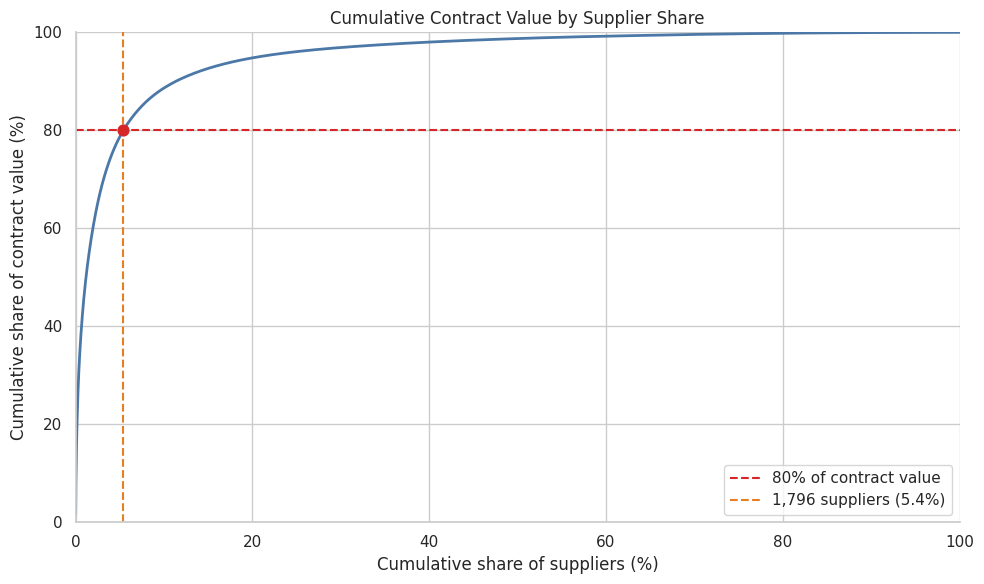

In [ ]:
fig, ax = plt.subplots(
    figsize=(10, 6)
)

ax.plot(
    supplier_pareto[
        'cumulative_supplier_pct'
    ],
    supplier_pareto[
        'cumulative_value_pct'
    ],
    color='#4C78A8',
    linewidth=2
)

ax.axhline(
    y=80,
    color='#D62728',
    linestyle='--',
    linewidth=1.5,
    label='80% of contract value'
)

ax.axvline(
    x=(
        supplier_count_80
        / total_suppliers
        * 100
    ),
    color='#E67E22',
    linestyle='--',
    linewidth=1.5,
    label=(
        f'{supplier_count_80:,} suppliers '
        f'({supplier_count_80 / total_suppliers * 100:.1f}%)'
    )
)

ax.scatter(
    supplier_count_80
    / total_suppliers
    * 100,
    80,
    color='#D62728',
    s=60,
    zorder=3
)

ax.set_title(
    'Cumulative Contract Value '
    'by Supplier Share'
)

ax.set_xlabel(
    'Cumulative share of suppliers (%)'
)

ax.set_ylabel(
    'Cumulative share of contract value (%)'
)

ax.set_xlim(0, 100)
ax.set_ylim(0, 100)

ax.legend(
    loc='lower right'
)

ax.spines[
    ['top', 'right']
].set_visible(False)

plt.tight_layout()
plt.show()

## 4. EDA Summary and Candidate Findings

การวิเคราะห์เชิงสำรวจพบรูปแบบสำคัญสำหรับนำไปศึกษาเพิ่มเติม
ใน Notebook การวิเคราะห์ Red Flag ดังนี้

### 1. Project-value Distribution

โครงการจ้างก่อสร้างมีวงเงินงบประมาณแบบเบ้ขวาอย่างมาก
โดย 76.34% ของโครงการมีวงเงินไม่เกิน 500,000 บาท
ขณะที่โครงการมูลค่าเกิน 50 ล้านบาทมีเพียง 0.49%

แม้โครงการขนาดใหญ่มีจำนวนน้อย แต่มีอิทธิพลต่อมูลค่ารวมสูง
จึงไม่ควรประเมินความสำคัญจากจำนวนโครงการเพียงอย่างเดียว

### 2. Concentration around 500,000 Baht

โครงการเฉพาะเจาะจงจำนวน 99.57% มีวงเงินไม่เกิน 500,000 บาท
และ 19.14% อยู่ในช่วง 490,000–500,000 บาท

การกระจุกตัวบริเวณดังกล่าวเป็น Candidate Finding ที่ควรตรวจสอบ
ร่วมกับหน่วยงาน ผู้รับจ้าง ชื่อโครงการ และช่วงเวลาของรายการ
แต่ยังไม่สามารถสรุปว่าเกิดการแบ่งโครงการหรือหลีกเลี่ยงขั้นตอนจัดซื้อ

### 3. Procurement-method Differences

วิธีเฉพาะเจาะจงคิดเป็น 76.35% ของจำนวนโครงการ
แต่มีวงเงินเพียง 9.33% ของทั้งหมด

e-bidding มีจำนวนเพียง 21.22% ของโครงการ แต่ครองวงเงิน
ถึง 83.34% และมีส่วนต่างจากราคากลางมัธยฐาน 6.60%
สูงกว่าวิธีเฉพาะเจาะจงซึ่งมีค่ามัธยฐาน 0.22%

### 4. Agency and Geographic Differences

กรมทางหลวงมีวงเงินรวมสูงที่สุดประมาณ 95.33 พันล้านบาท
หรือ 20.03% ของวงเงินทั้งหมด

กรุงเทพมหานครมีเพียง 2.70% ของจำนวนโครงการ
แต่ครองวงเงินรวม 37.30% แสดงว่าจำนวนโครงการและมูลค่า
ให้ภาพการกระจายที่แตกต่างกัน

ข้อมูลพื้นที่จะใช้เป็นบริบทประกอบ แต่ไม่ใช่แกนหลักของ Red Flag

### 5. Supplier Concentration

ผู้รับจ้างที่ได้โครงการจำนวนมากที่สุดไม่ใช่ผู้รับจ้าง
ที่ได้รับมูลค่ารวมสูงที่สุด

ผู้รับจ้างเพียง 1,796 ราย หรือ 5.40% ครองมูลค่าสัญญา
80% ของข้อมูลที่ผ่านการ Reconciliation อย่างไรก็ตาม
ผู้รับจ้าง 10 อันดับแรกครองมูลค่าเพียง 7.67%
จึงไม่ใช่การกระจุกตัวในผู้รับจ้างไม่กี่รายเท่านั้น

### 6. Data-quality Findings

มี 362 โครงการ หรือ 0.20% ที่ผลรวมวงเงินระดับสัญญา
ไม่ตรงกับราคาตกลงระดับโครงการ และพบส่วนต่างราคาร้อยละ
ที่สูงผิดสังเกตจากราคากลางซึ่งมีค่าต่ำมากบางรายการ

กรณีเหล่านี้ควรถูกแยกเป็น Data-quality Red Flag
ไม่ควรรวมกับ Procurement Red Flag โดยอัตโนมัติ

## Candidate Analyses for the Next Notebook

1. โครงการเฉพาะเจาะจงที่มีวงเงินใกล้ 500,000 บาท
2. โครงการที่ราคาตกลงสูงกว่างบประมาณ
3. โครงการที่ราคาตกลงสูงกว่าราคากลาง
4. โครงการที่มีส่วนต่างราคาร้อยละรุนแรงจาก denominator ผิดสังเกต
5. โครงการที่ยอดรวมระดับสัญญาไม่ตรงกับราคาตกลงระดับโครงการ
6. ผู้รับจ้างที่ได้หลายโครงการจากหน่วยงานหรือพื้นที่เดียวกัน
7. โครงการที่อาจมีชื่อหรือรายละเอียดคล้ายกันและเกิดในช่วงใกล้กัน

Candidate เหล่านี้เป็นหัวข้อสำหรับตรวจสอบต่อ
ยังไม่ใช่เกณฑ์ยืนยันการทุจริต

In [ ]:
project_output_path = (
    data_path.parent
    / 'construction_projects_2569.csv'
)

project_data.to_csv(
    project_output_path,
    index=False,
    encoding='utf-8-sig'
)

print(
    f'Project-level data saved to:\n'
    f'{project_output_path}'
)

Project-level data saved to:
/content/drive/MyDrive/learning/dads/dads5001/project_1_dads5001/dataset/procurement/egp-contract/processed/construction_projects_2569.csv


In [ ]:
supplier_output_path = (
    data_path.parent
    / 'construction_supplier_summary_2569.csv'
)

supplier_summary.to_csv(
    supplier_output_path,
    index=False,
    encoding='utf-8-sig'
)

print(
    f'Supplier summary saved to:\n'
    f'{supplier_output_path}'
)

Supplier summary saved to:
/content/drive/MyDrive/learning/dads/dads5001/project_1_dads5001/dataset/procurement/egp-contract/processed/construction_supplier_summary_2569.csv


In [ ]:
output_files = [
    project_output_path,
    supplier_output_path
]

for file_path in output_files:
    print(
        f'{file_path.name}: '
        f'{file_path.stat().st_size / (1024 ** 2):,.2f} MB'
    )

construction_projects_2569.csv: 239.88 MB
construction_supplier_summary_2569.csv: 4.59 MB


## 5. Output for Red Flag Analysis

Notebook นี้สร้างข้อมูลสำหรับใช้ในขั้นต่อไปจำนวน 2 ไฟล์:

1. `construction_projects_2569.csv`  
   ข้อมูลระดับโครงการ พร้อมตัวแปรส่วนต่างราคาและช่วงวงเงิน

2. `construction_supplier_summary_2569.csv`  
   ข้อมูลสรุประดับผู้รับจ้าง โดยใช้เลขประจำตัวนิติบุคคลเป็นรหัสหลัก

Notebook ถัดไปจะใช้ผลจาก EDA นี้กำหนด Red Flag
โดยแยก Procurement Red Flag ออกจาก Data-quality Red Flag
และตรวจสอบกรณีศึกษาจากข้อมูลจริง